In [1]:
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd

In [2]:
df_dir = 'dataset/'

In [3]:
def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = p.glob('*')

    img_list = []

    for dir in dirs:
        label = dir.name
        for file in dir.glob('*.jpg'):
            img = mpimg.imread(file)

            if not img is None:
                img_list.append((img, label))
    
    return img_list

In [4]:
df = load_dataset(df_dir)

In [5]:
import matplotlib.pyplot as plt

def img_viz(img_list, num_img):
    if num_img < 0 or num_img >= len(img_list):
        raise IndexError("num_img out of range")
    
    img, label = img_list[num_img]

    img = np.array(img)

    cmap = "gray" if len(img.shape) == 2 else None

    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap=cmap)
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

    print(f"Shape\t: {img.shape}")
    print(f"Label\t: {label}")


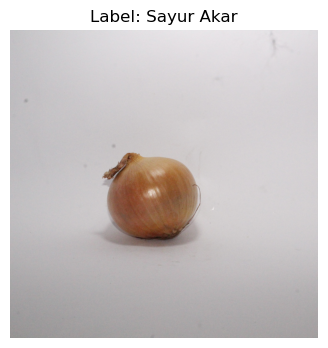

Shape	: (3456, 3456, 3)
Label	: Sayur Akar


In [6]:
img_viz(df, 0)

In [7]:
def crop_center(img, ratio=0.8):
    h, w = img.shape[:2]
    ch, cw = int(h * ratio), int(w * ratio)
    y1 = (h - ch) // 2
    x1 = (w - cw) // 2
    return img[y1:y1+ch, x1:x1+cw]

In [8]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=1.2, tileGridSize=(8,8))
    cl = clahe.apply(l)

    limg = cv2.merge((cl, a, b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

In [9]:
def segment_object_hsv(img):
    """Segmentasi menggunakan HSV color space"""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Buat mask untuk objek non-hitam/putih
    lower = np.array([0, 30, 30])  # Hindari warna gelap
    upper = np.array([180, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    
    # Morphological operations untuk membersihkan noise
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    # Cari contour terbesar (asumsi objek adalah area terbesar)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        mask_final = np.zeros_like(mask)
        cv2.drawContours(mask_final, [largest_contour], -1, 255, -1)
    else:
        mask_final = mask
    
    # Apply mask
    mask3 = np.repeat(mask_final[..., None], 3, axis=2).astype("uint8") // 255
    masked_bgr = img * mask3
    masked_rgb = cv2.cvtColor(masked_bgr, cv2.COLOR_BGR2RGB)
    
    return masked_rgb

In [10]:
def preprocessing_basic(img_list):
    result = []
    for img, label in img_list:
        
        #cropped = crop_center(img)
        resized = cv2.resize(img, (224, 224))
        clahe = apply_clahe(resized)
        seg_mask = segment_object_hsv(clahe)   

        final_img = clahe * (seg_mask > 0)

        result.append((final_img, label))
    
    return result


In [11]:
basic = preprocessing_basic(df)

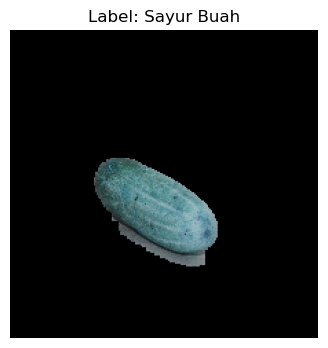

Shape	: (224, 224, 3)
Label	: Sayur Buah


In [12]:
img_viz(basic, 67)

In [13]:
def augment_img_deterministic(img):
    out = []

    out.append(img.copy())

    out.append(cv2.flip(img, 1))

    out.append(cv2.flip(img, 0))

    out.append(cv2.convertScaleAbs(img, alpha=1.2, beta=10))

    out.append(cv2.convertScaleAbs(img, alpha=0.8, beta=-10))

    h, w = img.shape[:2]
    M1 = cv2.getRotationMatrix2D((w//2, h//2), 15, 1)
    out.append(cv2.warpAffine(img, M1, (w, h)))

    M2 = cv2.getRotationMatrix2D((w//2, h//2), -15, 1)
    out.append(cv2.warpAffine(img, M2, (w, h)))

    M3 = cv2.getAffineTransform(
        np.float32([[0, 0], [w, 0], [0, h]]),
        np.float32([[0, 0], [w*1.5, 0], [0, h*1.5]])
    )
    zoomed = cv2.warpAffine(img, M3, (w, h))
    out.append(zoomed)

    return out        

In [14]:
def apply_augmentation(processed_list):
    augmented = []
    for img, label in processed_list:
        augs = augment_img_deterministic(img)
        for aug_img in augs:
            augmented.append((aug_img, label))
    return augmented


In [15]:
aug = apply_augmentation(basic)

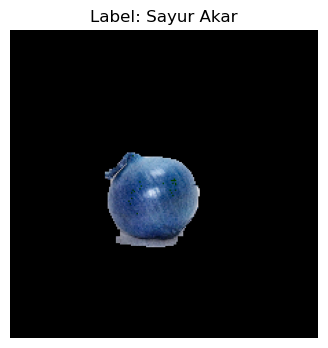

Shape	: (224, 224, 3)
Label	: Sayur Akar


In [16]:
img_viz(aug, 0)

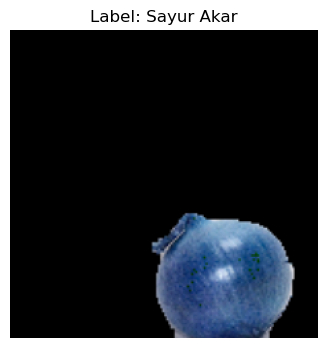

Shape	: (224, 224, 3)
Label	: Sayur Akar


In [17]:
img_viz(aug, 7)

In [18]:
def preprocess_for_shape(processed_list):
    result = []
    for img, label in processed_list:

        # grayscale
        grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # gaussian blur
        blurred = cv2.GaussianBlur(grey, (3,3), 0)

        # threshold (binerisasi objek)
        _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

        result.append((thresh, label))
    return result

In [19]:
shape_img = preprocess_for_shape(aug)

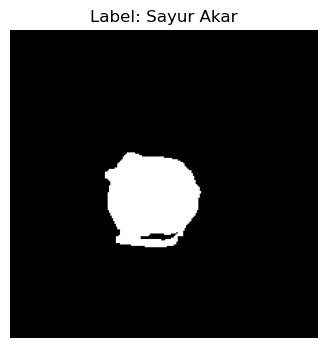

Shape	: (224, 224)
Label	: Sayur Akar


In [20]:
img_viz(shape_img, 0)

In [21]:
def preprocess_for_HSV(processed_list):
    result = []
    for img, label in processed_list:
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        result.append((hsv, label))
    return result

In [22]:
hsv_img = preprocess_for_HSV(aug)

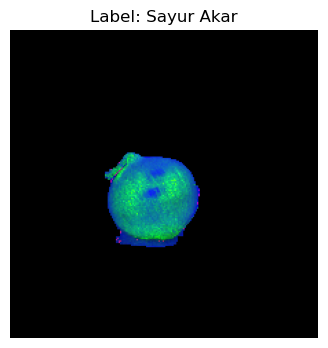

Shape	: (224, 224, 3)
Label	: Sayur Akar


In [23]:
img_viz(hsv_img, 0)

In [24]:
def preprocess_for_GLCM(processed_list):
    result = []
    for img, label in processed_list:
        grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        result.append((grey, label))
    return result

In [25]:
glcm_img = preprocess_for_GLCM(aug)

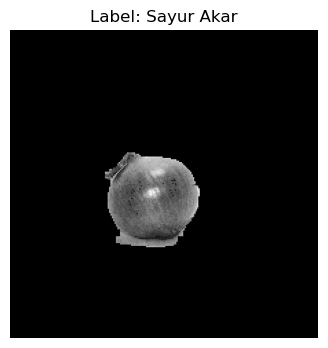

Shape	: (224, 224)
Label	: Sayur Akar


In [26]:
img_viz(glcm_img, 0)

In [27]:
from skimage.feature import graycomatrix, graycoprops
import numpy as np

def extract_GLCM(img_list):
    features = []

    distances = [1, 2]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]

    for img, label in img_list:
        glcm = graycomatrix(img, distances=distances, angles=angles, symmetric=True, normed=True)

        contrast = graycoprops(glcm, 'contrast').flatten()
        homogeneity = graycoprops(glcm, 'homogeneity').flatten()
        energy = graycoprops(glcm, 'energy').flatten()
        correlation = graycoprops(glcm, 'correlation').flatten()

        glcm_feat = np.hstack([contrast, homogeneity, energy, correlation])
        features.append((glcm_feat, label))

    return features


In [28]:
glcm_feat = extract_GLCM(glcm_img)

In [29]:
glcm_feat[0]

(array([ 89.63372838, 132.48776368,  96.55565343, 136.57580084,
        155.78780566, 132.48776368, 174.70592021, 136.57580084,
          0.93102152,   0.92917834,   0.93143869,   0.92934366,
          0.92860487,   0.92917834,   0.92798381,   0.92934366,
          0.92474874,   0.92358681,   0.92464865,   0.92354661,
          0.92302219,   0.92358681,   0.92282109,   0.92354661,
          0.95145556,   0.92854377,   0.94770674,   0.92633892,
          0.91597864,   0.92854377,   0.9057755 ,   0.92633892]),
 'Sayur Akar')

In [30]:
import numpy as np

def extract_HSV_hist(img_list, bins=(8, 8, 8)):
    features = []
    for img, label in img_list:

        hist = cv2.calcHist(
            [img],
            [0, 1, 2],    # H, S, V channel
            None,
            bins,
            [0, 180, 0, 256, 0, 256]
        )

        hist = cv2.normalize(hist, hist).flatten()
        features.append((hist, label))

    return features


In [31]:
hsv_feat = extract_HSV_hist(hsv_img)

In [32]:
hsv_feat[0]

(array([9.99779046e-01, 0.00000000e+00, 0.00000000e+00, 1.29042601e-04,
        6.88227185e-04, 3.22606502e-04, 3.44113592e-04, 1.07535496e-04,
        0.00000000e+00, 0.00000000e+00, 2.36578097e-04, 6.23705913e-04,
        3.76374251e-03, 1.95714599e-03, 8.38776876e-04, 5.16170403e-04,
        0.00000000e+00, 6.45213004e-05, 2.58085201e-04, 2.79592292e-04,
        1.80659641e-03, 1.97865325e-03, 3.87127791e-03, 8.60283981e-05,
        0.00000000e+00, 1.50549691e-04, 1.29042601e-04, 1.26891886e-03,
        6.10801624e-03, 5.20471809e-03, 1.46248273e-03, 0.00000000e+00,
        0.00000000e+00, 3.44113592e-04, 6.45213004e-04, 6.00048061e-03,
        1.31623447e-02, 2.94647273e-03, 2.15070995e-05, 0.00000000e+00,
        0.00000000e+00, 5.16170403e-04, 8.60283966e-04, 6.45212969e-03,
        7.24789267e-03, 2.15070992e-04, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 2.15070992e-04, 4.30141983e-04, 3.46264313e-03,
        1.80659641e-03, 0.00000000e+00, 0.00000000e+00, 0.000000

In [39]:
from skimage.measure import label as sk_label, regionprops
import numpy as np

def extract_shape_feature(preprocessed_list):
    features = []

    for img, lbl in preprocessed_list:
        labeled = sk_label(img)
        regions = regionprops(labeled)

        if len(regions) > 0:
            region = max(regions, key=lambda r: r.area)

            area = region.area
            perimeter = region.perimeter

            circularity = (4 * np.pi * area) / (perimeter**2) if perimeter > 0 else 0
            eccentricity = region.eccentricity

            feature_vector = np.array([circularity, eccentricity], dtype=np.float32)
        else:
            feature_vector = np.array([0, 0], dtype=np.float32)

        features.append((feature_vector, lbl))

    return features


In [40]:
shape_feat = extract_shape_feature(shape_img)

In [41]:
shape_feat[0]

(array([0.4863149 , 0.14306495], dtype=float32), 'Sayur Akar')

In [42]:
print(f"shape_feat shape: {len(shape_feat)} samples")
print(f"shape_feat[0][0] shape: {shape_feat[0][0].shape}")  # shape of feature vector

print(f"\nhsv_feat shape: {len(hsv_feat)} samples")
print(f"hsv_feat[0][0] shape: {hsv_feat[0][0].shape}")  # shape of feature vector

print(f"\nglcm_feat shape: {len(glcm_feat)} samples")
print(f"glcm_feat[0][0] shape: {glcm_feat[0][0].shape}")  # shape of feature vector


shape_feat shape: 1096 samples
shape_feat[0][0] shape: (2,)

hsv_feat shape: 1096 samples
hsv_feat[0][0] shape: (512,)

glcm_feat shape: 1096 samples
glcm_feat[0][0] shape: (32,)


In [43]:
# Extract features and labels from each feature list
hog_features = np.array([feat[0] for feat in shape_feat])
hsv_features = np.array([feat[0] for feat in hsv_feat])
glcm_features = np.array([feat[0] for feat in glcm_feat])
labels = np.array([feat[1] for feat in shape_feat])

# Combine all features horizontally
combined_features = np.hstack([hog_features, hsv_features, glcm_features])

# Create dataframe
df_features = pd.DataFrame(combined_features)
df_features['label'] = labels

print(f"Combined dataframe shape: {df_features.shape}")
print(f"Total rows: {len(df_features)}")
print(f"Features columns: {combined_features.shape[1]}")
print(df_features.head())

Combined dataframe shape: (1096, 547)
Total rows: 1096
Features columns: 546
          0         1         2    3         4         5         6         7  \
0  0.486315  0.143065  0.999779  0.0  0.000000  0.000129  0.000688  0.000323   
1  0.486315  0.143065  0.999779  0.0  0.000000  0.000129  0.000688  0.000323   
2  0.486315  0.143065  0.999779  0.0  0.000000  0.000129  0.000688  0.000323   
3  0.488687  0.151141  0.999791  0.0  0.000000  0.000000  0.000108  0.000710   
4  0.248850  0.184759  0.999761  0.0  0.000022  0.000624  0.000237  0.000258   

          8         9  ...       537       538       539       540       541  \
0  0.000344  0.000108  ...  0.923547  0.951456  0.928544  0.947707  0.926339   
1  0.000344  0.000108  ...  0.923587  0.951456  0.926339  0.947707  0.928544   
2  0.000344  0.000108  ...  0.923587  0.951456  0.926339  0.947707  0.928544   
3  0.000624  0.000559  ...  0.923546  0.951881  0.929119  0.947980  0.927072   
4  0.000000  0.000000  ...  0.923547  0.94

In [44]:
X = df_features.drop('label', axis=1).values
y = df_features['label'].values

In [45]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
X_train_scaled

array([[-0.37551315,  1.01240058,  0.51499007, ...,  0.35020938,
         0.12020257,  0.40117951],
       [ 0.6434996 , -1.66584797,  0.59683121, ...,  0.39738144,
         0.40063933,  0.39656543],
       [ 1.85146628,  1.06774453,  0.64428031, ..., -2.264996  ,
        -1.91603027, -0.75998435],
       ...,
       [ 0.45127568,  0.46531586,  0.63270643, ...,  0.06086136,
        -0.35980737,  0.26989531],
       [ 0.23048574,  1.2740875 ,  0.64291122, ..., -2.55604308,
        -0.82506851, -3.15857218],
       [ 0.33845648, -0.83963485, -0.6238136 , ...,  0.87133986,
         0.96291428,  0.84707757]], shape=(876, 546))

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

print("\n[1/3] Applying LDA...")
lda = LinearDiscriminantAnalysis(n_components=min(3, len(np.unique(y_train)) - 1))
X_train_reduced = lda.fit_transform(X_train_scaled, y_train)
X_test_reduced = lda.transform(X_test_scaled)
print(f"LDA - Reduced to {X_train_reduced.shape[1]} components")


[1/3] Applying LDA...
LDA - Reduced to 3 components


## Metode SVM tanpa reduksi fitur

In [49]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}


print("Parameter grid:")
for param, values in param_grid.items():
    print(f"  - {param}: {values}")

svm = SVC(random_state=42)
grid_search = GridSearchCV(
    svm, 
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=2,
    return_train_score=True
)

grid_search.fit(X_train_scaled, y_train)

print("\n" + "="*70)
print("GRID SEARCH RESULTS")
print("="*70)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print(f"Total combinations tested: {len(grid_search.cv_results_['params'])}")

best_model = grid_search.best_estimator_

cv_results = pd.DataFrame(grid_search.cv_results_)
top_5 = cv_results.nlargest(5, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
print("\nTop 5 parameter combinations:")
print(top_5.to_string(index=False))

Parameter grid:
  - C: [0.1, 1, 10, 100]
  - gamma: ['scale', 'auto', 0.001, 0.01, 0.1, 1]
  - kernel: ['rbf']
Fitting 5 folds for each of 24 candidates, totalling 120 fits

GRID SEARCH RESULTS
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.9909
Total combinations tested: 24

Top 5 parameter combinations:
                                      params  mean_test_score  std_test_score  rank_test_score
 {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}         0.990864        0.009287                1
  {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}         0.989721        0.008402                2
 {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}         0.988578        0.007233                3
{'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}         0.988578        0.007233                3
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}         0.985149        0.009291                5


In [50]:
from sklearn.metrics import classification_report
y_pred = best_model.predict(X_test_scaled)
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Sayur Akar       0.98      1.00      0.99        58
  Sayur Buah       1.00      0.98      0.99        53
 Sayur Bunga       1.00      1.00      1.00        48
  Sayur Daun       1.00      1.00      1.00        61

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220



In [51]:
train_acc = best_model.score(X_train_scaled, y_train)
test_acc = best_model.score(X_test_scaled, y_test)
print("\n" + "="*70)
print("FINAL MODEL ACCURACY")
print("="*70)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


FINAL MODEL ACCURACY
Training Accuracy: 1.0000
Test Accuracy: 0.9955


In [52]:
import joblib

joblib.dump(best_model, 'svm_kategori_sayur_model_segmentasi.joblib')

['svm_kategori_sayur_model_segmentasi.joblib']

## Metode KNN tanpa reduksi fitur

In [53]:
from sklearn.neighbors import KNeighborsClassifier

# =====================================
# KNN GRID SEARCH
# =====================================

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2],  # Manhattan(1) & Euclidean(2)
    'metric': ['minkowski']
}

print("Parameter grid (KNN):")
for param, values in knn_param_grid.items():
    print(f"  - {param}: {values}")

knn = KNeighborsClassifier()

knn_grid_search = GridSearchCV(
    knn,
    knn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

knn_grid_search.fit(X_train_scaled, y_train)

print("\n" + "="*70)
print("KNN - GRID SEARCH RESULTS")
print("="*70)
print(f"Best parameters: {knn_grid_search.best_params_}")
print(f"Best cross-validation score: {knn_grid_search.best_score_:.4f}")
print(f"Total combinations tested: {len(knn_grid_search.cv_results_['params'])}")

knn_best_model = knn_grid_search.best_estimator_

knn_cv_results = pd.DataFrame(knn_grid_search.cv_results_)
knn_top_5 = knn_cv_results.nlargest(5, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
print("\nTop 5 parameter combinations:")
print(knn_top_5.to_string(index=False))


Parameter grid (KNN):
  - n_neighbors: [3, 5, 7, 9, 11]
  - weights: ['uniform', 'distance']
  - p: [1, 2]
  - metric: ['minkowski']
Fitting 5 folds for each of 20 candidates, totalling 100 fits

KNN - GRID SEARCH RESULTS
Best parameters: {'metric': 'minkowski', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Best cross-validation score: 0.9886
Total combinations tested: 20

Top 5 parameter combinations:
                                                                  params  mean_test_score  std_test_score  rank_test_score
{'metric': 'minkowski', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}         0.988584        0.012519                1
{'metric': 'minkowski', 'n_neighbors': 7, 'p': 1, 'weights': 'distance'}         0.988578        0.008857                2
{'metric': 'minkowski', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}         0.988578        0.011989                3
 {'metric': 'minkowski', 'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}         0.987442        0.

In [54]:
from sklearn.metrics import classification_report
y_pred = knn_best_model.predict(X_test_scaled)
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Sayur Akar       0.98      1.00      0.99        58
  Sayur Buah       1.00      0.98      0.99        53
 Sayur Bunga       1.00      1.00      1.00        48
  Sayur Daun       1.00      1.00      1.00        61

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220



In [55]:
train_acc = knn_best_model.score(X_train_scaled, y_train)
test_acc = knn_best_model.score(X_test_scaled, y_test)
print("\n" + "="*70)
print("FINAL MODEL ACCURACY")
print("="*70)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


FINAL MODEL ACCURACY
Training Accuracy: 1.0000
Test Accuracy: 0.9955


In [56]:
import joblib

joblib.dump(knn_best_model, 'knn_kategori_sayur_model_segmentasi.joblib')

['knn_kategori_sayur_model_segmentasi.joblib']

## Metode Random Forest tanpa reduksi fitur

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd

# =====================================
# RANDOM FOREST GRID SEARCH
# =====================================

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print("Parameter grid (Random Forest):")
for param, values in rf_param_grid.items():
    print(f"  - {param}: {values}")

rf = RandomForestClassifier(random_state=42)

rf_grid_search = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

rf_grid_search.fit(X_train_scaled, y_train)

print("\n" + "="*70)
print("RANDOM FOREST - GRID SEARCH RESULTS")
print("="*70)
print(f"Best parameters: {rf_grid_search.best_params_}")
print(f"Best cross-validation score: {rf_grid_search.best_score_:.4f}")
print(f"Total combinations tested: {len(rf_grid_search.cv_results_['params'])}")

rf_best_model = rf_grid_search.best_estimator_

rf_cv_results = pd.DataFrame(rf_grid_search.cv_results_)
rf_top_5 = rf_cv_results.nlargest(5, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
print("\nTop 5 parameter combinations:")
print(rf_top_5.to_string(index=False))


Parameter grid (Random Forest):
  - n_estimators: [100, 200, 300]
  - max_depth: [None, 10, 20, 30]
  - min_samples_split: [2, 5, 10]
  - min_samples_leaf: [1, 2, 4]
  - max_features: ['sqrt', 'log2']
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

RANDOM FOREST - GRID SEARCH RESULTS
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score: 0.9966
Total combinations tested: 216

Top 5 parameter combinations:
                                                                                                         params  mean_test_score  std_test_score  rank_test_score
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}         0.996571        0.004571                1
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}         0.996571        0.004571   

In [58]:
from sklearn.metrics import classification_report
y_pred = rf_best_model.predict(X_test_scaled)
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Sayur Akar       0.98      1.00      0.99        58
  Sayur Buah       0.98      0.96      0.97        53
 Sayur Bunga       0.98      1.00      0.99        48
  Sayur Daun       1.00      0.98      0.99        61

    accuracy                           0.99       220
   macro avg       0.99      0.99      0.99       220
weighted avg       0.99      0.99      0.99       220



In [59]:
train_acc = rf_best_model.score(X_train_scaled, y_train)
test_acc = rf_best_model.score(X_test_scaled, y_test)
print("\n" + "="*70)
print("FINAL MODEL ACCURACY")
print("="*70)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


FINAL MODEL ACCURACY
Training Accuracy: 1.0000
Test Accuracy: 0.9864


In [60]:
import joblib

joblib.dump(rf_best_model, 'rf_kategori_sayur_model_segmentasi.joblib')

['rf_kategori_sayur_model_segmentasi.joblib']

## Testing dengan gambar lain

In [61]:
val_dir = 'validation/'

In [62]:
def load_dataset_without_subfolder(img_dir):
    p = Path(img_dir)
    img_list = []

    for file in p.glob("*"):
        if file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            
            img = mpimg.imread(file)
            if img is None:
                continue

            label = file.stem   # nama file tanpa ekstensi
            img_list.append((img, label))

    return img_list

In [63]:
val_image = load_dataset_without_subfolder(val_dir)

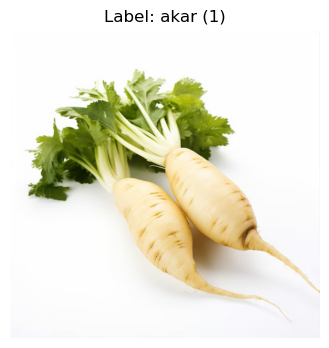

Shape	: (752, 756, 3)
Label	: akar (1)


In [64]:
img_viz(val_image, 0)

In [65]:
val_features = []
val_filenames = []

for img, filename in val_image:
    
    # preprocessing umum
    basic = preprocessing_basic([(img, "unknown")])
    
    # preprocessing khusus fitur
    shape_imgf  = preprocess_for_shape(basic)
    hsv_img  = preprocess_for_HSV(basic)
    glcm_img = preprocess_for_GLCM(basic)

    # ekstraksi fitur
    shape_f = extract_shape_feature(shape_imgf)[0][0]
    hsv_f  = extract_HSV_hist(hsv_img)[0][0]
    #hsv_f = pca_hsv.transform(hsv_f.reshape(1, -1)).flatten()
    glcm_f = extract_GLCM(glcm_img)[0][0]

    combined = np.hstack([shape_f, hsv_f, glcm_f])

    val_features.append(combined)
    val_filenames.append(filename)


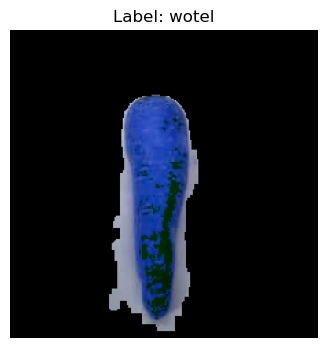

Shape	: (224, 224, 3)
Label	: wotel


In [66]:
basic_test = preprocessing_basic(val_image)
img_viz(basic_test, 10)

In [67]:
val_scaled = scaler.transform(val_features)

In [ ]:
val_reduced = lda.transform(val_scaled)

In [68]:
svm_model = joblib.load('svm_kategori_sayur_model_segmentasi.joblib')
knn_model = joblib.load('knn_kategori_sayur_model_segmentasi.joblib')
rf_model  = joblib.load('rf_kategori_sayur_model_segmentasi.joblib')

svm_pred = svm_model.predict(val_scaled)
knn_pred = knn_model.predict(val_scaled)
rf_pred  = rf_model.predict(val_scaled)

In [69]:
for f, s, k, r in zip(val_filenames, svm_pred, knn_pred, rf_pred):
    print(f"{f} => SVM: {s}, KNN: {k}, RF: {r}")

akar (1) => SVM: 3, KNN: 3, RF: 3
akar (2) => SVM: 3, KNN: 1, RF: 1
akar (3) => SVM: 3, KNN: 0, RF: 3
akar (4) => SVM: 3, KNN: 0, RF: 3
akar (5) => SVM: 3, KNN: 0, RF: 3
buah (1) => SVM: 3, KNN: 0, RF: 3
buah (2) => SVM: 3, KNN: 2, RF: 3
bunga (1) => SVM: 3, KNN: 2, RF: 2
bunga (2) => SVM: 3, KNN: 3, RF: 3
daun => SVM: 3, KNN: 3, RF: 3
wotel => SVM: 1, KNN: 1, RF: 0


In [70]:
label_encoder = LabelEncoder()
label_encoder.fit(y)      # y = daftar label asli saat training

LabelEncoder()

In [71]:
svm_labels = label_encoder.inverse_transform(svm_pred)
knn_labels = label_encoder.inverse_transform(knn_pred)
rf_labels  = label_encoder.inverse_transform(rf_pred)

In [72]:
for f, s, k, r in zip(val_filenames, svm_labels, knn_labels, rf_labels):
    print(f"{f} => SVM: {s}, KNN: {k}, RF: {r}")

akar (1) => SVM: Sayur Daun, KNN: Sayur Daun, RF: Sayur Daun
akar (2) => SVM: Sayur Daun, KNN: Sayur Buah, RF: Sayur Buah
akar (3) => SVM: Sayur Daun, KNN: Sayur Akar, RF: Sayur Daun
akar (4) => SVM: Sayur Daun, KNN: Sayur Akar, RF: Sayur Daun
akar (5) => SVM: Sayur Daun, KNN: Sayur Akar, RF: Sayur Daun
buah (1) => SVM: Sayur Daun, KNN: Sayur Akar, RF: Sayur Daun
buah (2) => SVM: Sayur Daun, KNN: Sayur Bunga, RF: Sayur Daun
bunga (1) => SVM: Sayur Daun, KNN: Sayur Bunga, RF: Sayur Bunga
bunga (2) => SVM: Sayur Daun, KNN: Sayur Daun, RF: Sayur Daun
daun => SVM: Sayur Daun, KNN: Sayur Daun, RF: Sayur Daun
wotel => SVM: Sayur Buah, KNN: Sayur Buah, RF: Sayur Akar


In [76]:
actual_labels = ['Sayur Akar', 'Sayur Akar', 'Sayur Akar', 'Sayur Akar', 'Sayur Akar', 'Sayur Buah', 'Sayur Buah', 'Sayur Bunga', 'Sayur Bunga', 'Sayur Daun', 'Sayur Akar']  # Isi dengan label sebenarnya jika ada

In [77]:
from sklearn.metrics import accuracy_score

# Calculate accuracy for each model on test set
svm_accuracy = accuracy_score(actual_labels, svm_labels) * 100
knn_accuracy = accuracy_score(actual_labels, knn_labels) * 100
rf_accuracy = accuracy_score(actual_labels, rf_labels) * 100

print("="*70)
print("MODEL ACCURACY ON TEST SET")
print("="*70)
print(f"SVM Accuracy: {svm_accuracy:.2f}%")
print(f"KNN Accuracy: {knn_accuracy:.2f}%")
print(f"RF  Accuracy: {rf_accuracy:.2f}%")
print("="*70)

MODEL ACCURACY ON TEST SET
SVM Accuracy: 9.09%
KNN Accuracy: 45.45%
RF  Accuracy: 27.27%


- menambah model yang lain
- memcoba reduksi dimensi